### 8.1: Loading Images

#### Problem

You want to load an image for preprocessing.

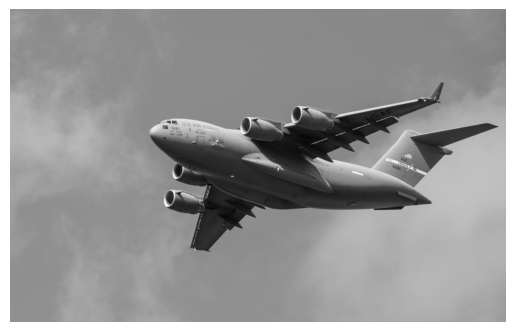

In [1]:
# Use OpenCV’s imread:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image as grayscale
image = cv2.imread("images/plane.jpg", cv2.IMREAD_GRAYSCALE)

# Show image
plt.imshow(image, cmap="gray"), plt.axis("off")
plt.show()

In a matrix representing a color image, each element actually contains three values corresponding to blue, green, and red values, respectively (BGR):

In [2]:
# Load image in color
image_bgr = cv2.imread("images/plane.jpg", cv2.IMREAD_COLOR)
# Show pixel
image_bgr[0,0]

array([195, 144, 111], dtype=uint8)

To properly display OpenCV color images in Matplotlib, we first need to convert the color to RGB.

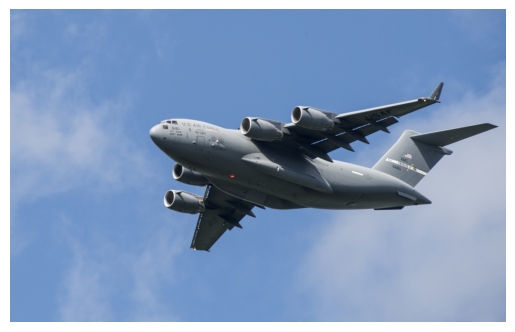

In [3]:
# Convert to RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
# Show image
plt.imshow(image_rgb), plt.axis("off")
plt.show()

#### 8.2 Saving Images

#### Problem

You want to save an image for preprocessing.

In [4]:
# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt
# Load image as grayscale
image = cv2.imread("images/plane.jpg", cv2.IMREAD_GRAYSCALE)
# Save image
cv2.imwrite("images/plane_new.jpg", image)

True

#### 8.3 Resizing Images

#### Problem

You want to resize an image for further preprocessing.

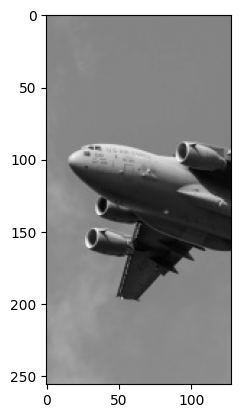

In [5]:
# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image as grayscale
image = cv2.imread("images/plane_256x256.jpg", cv2.IMREAD_GRAYSCALE)

# Resize image to 50 pixels by 50 pixels
image_50x50 = cv2.resize(image, (50, 50))

# Blur image
image_blurry = cv2.blur(image, (5,5))

# Crop image
image_cropped = image[:,:128]

# View image
plt.imshow(image_cropped, cmap="gray"), plt.axis("on")
plt.show()

#### Using the kernal

Highlighting the effect of the kernal size.

Setting the blur with a 100 x 100 kernal instead of 50x50.

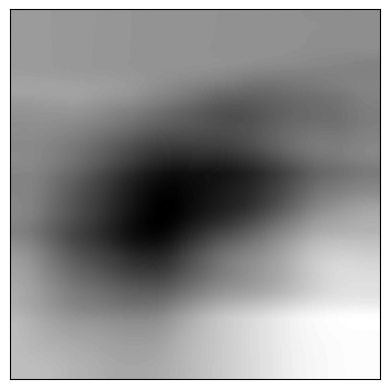

In [6]:
# Blur imag further
image_very_blurry = cv2.blur(image, (100,100))

# Show image
plt.imshow(image_very_blurry, cmap="gray"), plt.xticks([]), plt.yticks([])
plt.show()

#### 8.6 Sharpening Images

### Problem

You want to sharpen an image

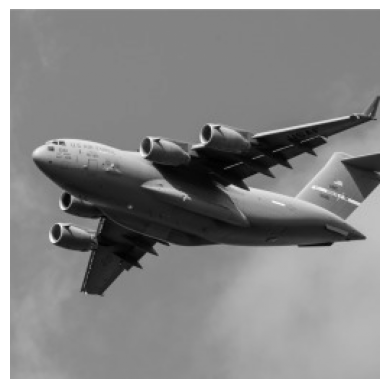

In [7]:
# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt
# Load image as grayscale
image = cv2.imread("images/plane_256x256.jpg", cv2.IMREAD_GRAYSCALE)
# Create kernel
kernel = np.array([[0, -1, 0],
[-1, 5,-1],
[0, -1, 0]])
# Sharpen image
image_sharp = cv2.filter2D(image, -1, kernel)
# Show image, with chosen setting.
plt.imshow(image, cmap="gray"), plt.axis("off")
plt.show()

### 8.8 Isolating Colors

#### Problem

You want to isolate a color in an image.

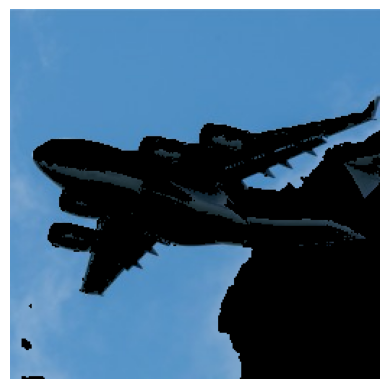

In [8]:
# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image
image_bgr = cv2.imread('images/plane_256x256.jpg')
# Convert BGR to HSV
image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

# Define range of blue values in HSV
lower_blue = np.array([50,100,50])
upper_blue = np.array([130,255,255])

# Create mask
mask = cv2.inRange(image_hsv, lower_blue, upper_blue)

# Mask image
image_bgr_masked = cv2.bitwise_and(image_bgr, image_bgr, mask=mask)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image_bgr_masked, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(image_rgb), plt.axis("off")
plt.show()

#### 8.11 Detecting Edges

#### Problem

You want to find the edges in an image.

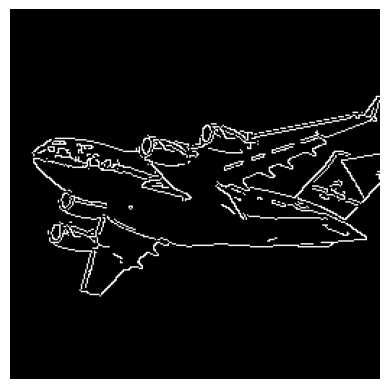

In [9]:
# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image as grayscale
image_gray = cv2.imread("images/plane_256x256.jpg", cv2.IMREAD_GRAYSCALE)

# Calculate median intensity
median_intensity = np.median(image_gray)

# Set thresholds to be one standard deviation above and below median intensity
lower_threshold = int(max(0, (1.0 - 0.33) * median_intensity))
upper_threshold = int(min(255, (1.0 + 0.33) * median_intensity))

# Apply Canny edge detector
image_canny = cv2.Canny(image_gray, lower_threshold, upper_threshold)

# Show image
plt.imshow(image_canny, cmap="gray"), plt.axis("off")
plt.show()

#### 8.12 Detecting Corners

#### Problem

You want to detect the corners in an image.

#### Solution

Use OpenCV’s implementation of the Harris corner detector, cornerHarris:

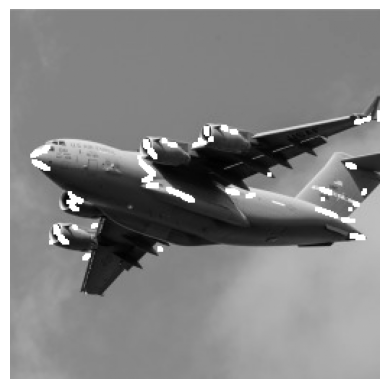

In [10]:
# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load image
image_bgr = cv2.imread("images/plane_256x256.jpg")
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
image_gray = np.float32(image_gray)

# Set corner detector parameters
block_size = 2
aperture = 29
free_parameter = 0.04

# Detect corners
detector_responses = cv2.cornerHarris(image_gray,
block_size,
aperture,
free_parameter)

# Large corner markers
detector_responses = cv2.dilate(detector_responses, None)

# Only keep detector responses greater than threshold, mark as white
threshold = 0.02
image_bgr[detector_responses >
threshold *
detector_responses.max()] = [255,255,255]

# Convert to grayscale
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# Show image
plt.imshow(image_gray, cmap="gray"), plt.axis("off")
plt.show()

The output is a grayscale image depicting potential corners:

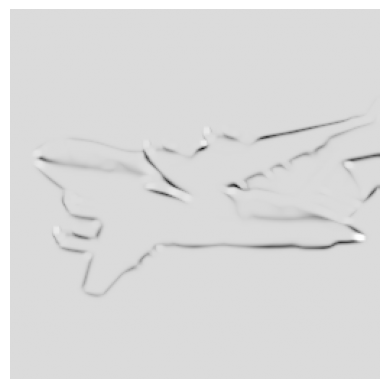

In [11]:
# Show potential corners
plt.imshow(detector_responses, cmap='gray'), plt.axis("off")
plt.show()

#### Using the Shi-Tomasi corner detector

`goodFeaturesToTrack` takes three major parameters—the number of corners to detect, the minimum quality of the corner (0 to 1) and the minimum Euclidean distance between corners:

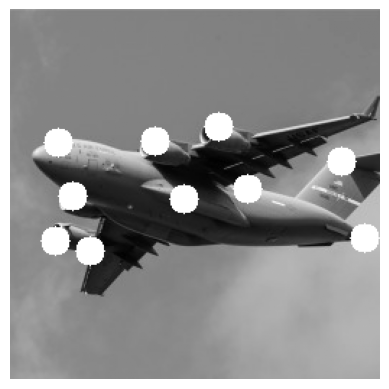

In [12]:
# Load images
image_bgr = cv2.imread('images/plane_256x256.jpg')
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# Number of corners to detect
corners_to_detect = 10
minimum_quality_score = 0.05
minimum_distance = 25

# Detect corners
corners = cv2.goodFeaturesToTrack(image_gray,
corners_to_detect,
minimum_quality_score,
minimum_distance)
corners = np.int16(corners)

# Draw white circle at each corner
for corner in corners:
    x, y = corner[0]
    cv2.circle(image_bgr, (x,y), 10, (255,255,255), -1)

# Convert to grayscale
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# Show image
plt.imshow(image_rgb, cmap='gray'), plt.axis("off")
plt.show()

#### 8.13 Creating Features for Machine Learning

#### Problem

Use NumPy’s flatten to convert the multidimensional array containing image data
into a vector containing the observation’s values:

In [13]:
# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [14]:
# Load image as grayscale
image = cv2.imread("images/plane_256x256.jpg", cv2.IMREAD_GRAYSCALE)

In [15]:
# Resize the image to 10 by 1 pixels
image_10x10 = cv2.resize(image, (10, 10))

In [16]:
# Convert image data to 1D vector
image_10x10.flatten()

array([133, 130, 130, 129, 130, 129, 129, 128, 128, 127, 135, 131, 131,
       131, 130, 130, 129, 128, 128, 128, 134, 132, 131, 131, 130, 129,
       129, 128, 130, 133, 132, 158, 130, 133, 130,  46,  97,  26, 132,
       143, 141,  36,  54,  91,   9,   9,  49, 144, 179,  41, 142,  95,
        32,  36,  29,  43, 113, 141, 179, 187, 141, 124,  26,  25, 132,
       135, 151, 175, 174, 184, 143, 151,  38, 133, 134, 139, 174, 177,
       169, 174, 155, 141, 135, 137, 137, 152, 169, 168, 168, 179, 152,
       139, 136, 135, 137, 143, 159, 166, 171, 175], dtype=uint8)

Show a 10x10 pixel image.

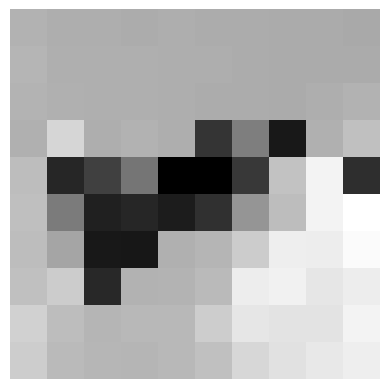

In [17]:
plt.imshow(image_10x10, cmap="gray"), plt.axis("off")
plt.show()

These are the dimensions of the image's data.

In [18]:
image_10x10.shape

(10, 10)

And if we flatten the array, we get a vector of length 100 (10 multiplied by 10):

In [19]:
image_10x10.flatten().shape

(100,)

When the image is in color, the dimensions are multiplied by (often three) the channels that blend to make the final color of that pixel.

In the case of this exercise, there will be 300 feature values for each observation.

In [25]:
# Load image in color
image_color = cv2.imread("images/plane_256x256.jpg", cv2.IMREAD_COLOR)

# Resize image to 10 x 10 px
image_color_10x10 = cv2.resize(image_color, (10, 10))

# Convert image data to 1D vector, show dimenstions
image_color_10x10.flatten().shape

(300,)

At normal size, the number of pixels at flatten will be 196,608, which are too many features. This is what motivates dimentionslity reduction strategies that reduce the number of features while not losing an excessive amount of information contained in the data.

#### 8.14 Encoding Color Histograms as Features

#### Problem

You want to create a set of features representing the colors appearing in an image.

In [ ]:
# Compute the histograms for each color channel

# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(0)

In [27]:
# Load image
image_bgr = cv2.imread("images/plane_256x256.jpg", cv2.IMREAD_COLOR)

# Convert to RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

In [30]:
# Create a list for feature values
features = []

# Calculate the historgram for each color channel
colors = ("r", "g", "b")

In the RGB color model, each color is the combination of three color channels (i.e.,
red, green, blue). In turn, each channel can take on one of 256 values (represented by
an integer between 0 and 255).

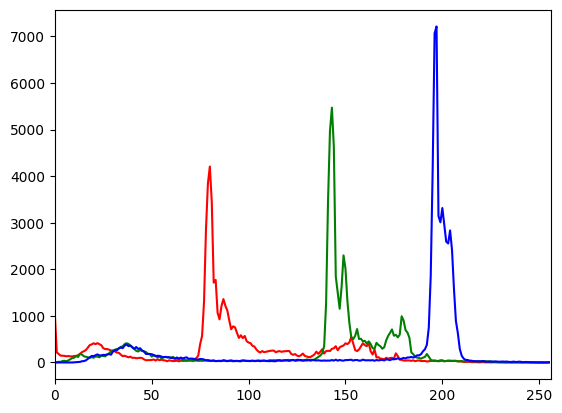

In [39]:
# For each channel: calculate histogram, make plot
for i, channel in enumerate(colors):
    histogram = cv2.calcHist([image_rgb], # Image
                        [i], # Index of channel
                        None, # No mask
                        [256], # Histogram size
                        [0,256]) # Range
    plt.plot(histogram, color = channel)
    plt.xlim([0,256])
# Show plot
plt.show()

In the histograph above, the x-axis represents the 256 possible channel values, and the y-axis rperesents the number of times a particular channel value appears across all pixels in an image.

In [40]:
# Create a vector for an observation's feature values
observation = np.array(features).flatten()

In [ ]:
# Show the observation's value for the first five features
observation[0:5]sfsgd

array([1027.,  217.,  182.,  146.,  146.], dtype=float32)

### 8.16 Detecting Objects with OpenCV

#### Problem

You want to detect objects in images using pretrained cascade classifiers with OpenCV.

#### Solution

Download and run one of OpenCV’s Haar cascade classifiers. In this case, we use a
pretrained face detection model to detect and draw a rectangle around a face in an
image: